# From Quantum Phase Noise to Dependent Bitstreams
## Qiskit 2.x and Aer computational companion

This notebook accompanies the paper **“From Quantum Phase Noise to Dependent Bitstreams: Measurement-Aware Statistical Inference and Multiscale Diagnostics.”** It implements the paper's central data-generating chain,

$$
\text{latent phase process}
\longrightarrow
\text{quantum circuit and channel}
\longrightarrow
\text{ordered bitstream}
\longrightarrow
\text{statistical diagnosis and mitigation}.
$$

The computational strategy follows the theory closely. Qiskit Aer is used to evaluate the conditional quantum experiment, including phase damping, depolarizing channels, basis rotations, and asymmetric readout. Once the circuit-to-probability map has been validated, large time-series and replication experiments sample from the resulting Bernoulli law. This is not an approximation to a different experiment. Conditional on the latent phase, the measured bit is Bernoulli with the probability supplied by the Aer-calibrated Ramsey response. Temporal dependence appears only after the latent phase is marginalized over acquisition blocks.

The intended repository is [github.com/BraniV/QNoise](https://github.com/BraniV/QNoise). The notebook regenerates the manuscript figures, records package versions and random seeds, writes numerical summaries as CSV files, and adds a sentinel-assisted mitigation experiment motivated directly by the covariance-transfer theorem.

## Paper-to-notebook correspondence

| Paper component | Notebook experiment | Figure |
|---|---|---|
| Measurement sensitivity to phase damping | Direct computational-basis readout versus a closing-H Ramsey readout | `fig01_phase_damping_basis_sensitivity.png` |
| Exact covariance-transfer proposition | Exact Gaussian formula and Aer-calibrated ordered simulations at two operating points | `fig12_covariance_transfer.png`, `fig12b_aer_operating_point.png` |
| Block variance decomposition | Fixed total-shot budget with varying shots per block | `fig13_block_allocation.png` |
| Bell and GHZ population/coherence distinction | Density-matrix simulation with depolarizing and phase-damping channels | `fig02_entanglement_degradation.png`, `fig11_ghz_size_scaling.png` |
| Static noise, persistent drift, and structural change | Ordered Ramsey streams with ACF, spectrum, DFA, wavelets, and CUSUM | `fig03` through `fig10` |
| Circuit construction for mitigation | Quadrature and near-fringe sentinels used for time-local target correction | `fig14_sentinel_mitigation.png` |

The notebook intentionally avoids treating a static Aer noise model as a temporal noise model. A fixed channel changes bias and contrast. Serial dependence is introduced through an ordered latent process that changes the circuit phase from block to block.

## 1. Environment and output directories

The code targets Qiskit 2.x and Qiskit Aer. It uses `AerSimulator` and `transpile` and does not use the obsolete `execute` helper. Aer calculations are deterministic density-matrix evaluations with explicit channel instructions. This keeps the quantum layer reproducible and makes the separation between quantum evolution and classical sampling transparent.

In [1]:
from __future__ import annotations

import json
import platform
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt
from scipy.linalg import toeplitz
from scipy.signal import welch
from statsmodels.tsa.stattools import acf

import qiskit
import qiskit_aer
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import depolarizing_error, phase_damping_error

ROOT = Path.cwd()
FIG_DIR = ROOT / "Figs"
RESULT_DIR = ROOT / "Results"
FIG_DIR.mkdir(exist_ok=True)
RESULT_DIR.mkdir(exist_ok=True)

SEED = 20260719
rng = np.random.default_rng(SEED)

VERSIONS = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "qiskit": qiskit.__version__,
    "qiskit_aer": qiskit_aer.__version__,
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "pywavelets": pywt.__version__,
}
print(json.dumps(VERSIONS, indent=2))


{
  "python": "3.13.5",
  "platform": "Linux-4.4.0-x86_64-with-glibc2.41",
  "qiskit": "2.4.2",
  "qiskit_aer": "0.17.2",
  "numpy": "2.3.5",
  "pandas": "2.2.3",
  "pywavelets": "1.8.0"
}


## 2. Aer density-matrix layer and statistical utilities

For a Ramsey block with latent phase $\epsilon_j$, the paper models the reported telegraph mean as

$$
m(\epsilon_j)=\delta-\kappa\cos(\phi_0+\epsilon_j).
$$

Here $\delta$ is the additive readout asymmetry and $\kappa$ is the remaining contrast after quantum attenuation and assignment error. The functions below construct the circuits, insert explicit CPTP channel instructions, extract density matrices from Aer, apply an independent readout channel, and provide the time-series diagnostics used later.

The fractional Gaussian process is generated from its exact Toeplitz covariance matrix. For the block lengths used in the notebook, direct Cholesky simulation is fast and avoids ambiguity about normalization conventions.

In [2]:
SIM = AerSimulator(
    method="density_matrix",
    max_parallel_threads=1,
    max_parallel_experiments=1,
)


def density_matrix(circuit: QuantumCircuit) -> np.ndarray:
    qc = circuit.copy()
    qc.save_density_matrix()
    compiled = transpile(qc, SIM, optimization_level=0, seed_transpiler=SEED)
    result = SIM.run(compiled, shots=1, seed_simulator=SEED).result()
    return np.asarray(result.data(0)["density_matrix"], dtype=complex)


def apply_readout_one_qubit(p1: float, p01: float, p10: float) -> float:
    return p01 * (1.0 - p1) + (1.0 - p10) * p1


def readout_matrix(n: int, p01: float, p10: float) -> np.ndarray:
    single = np.array([[1.0 - p01, p10], [p01, 1.0 - p10]])
    matrix = single
    for _ in range(n - 1):
        matrix = np.kron(matrix, single)
    return matrix


def ramsey_density_circuit(phi: float, p1_gate: float = 0.004, phase_damp: float = 0.025) -> QuantumCircuit:
    qc = QuantumCircuit(1)
    qc.h(0)
    qc.append(depolarizing_error(p1_gate, 1).to_instruction(), [0])
    qc.rz(float(phi), 0)
    qc.append(phase_damping_error(phase_damp).to_instruction(), [0])
    qc.h(0)
    qc.append(depolarizing_error(p1_gate, 1).to_instruction(), [0])
    return qc


def phase_damping_basis_circuit(damping: float, closing_h: bool, n_channels: int = 8) -> QuantumCircuit:
    qc = QuantumCircuit(1)
    qc.h(0)
    instruction = phase_damping_error(float(damping)).to_instruction()
    for _ in range(n_channels):
        qc.append(instruction, [0])
    if closing_h:
        qc.h(0)
    return qc


def ghz_density_circuit(
    n: int,
    basis: str,
    p1_gate: float,
    p2_gate: float,
    phase_damp: float,
) -> QuantumCircuit:
    qc = QuantumCircuit(n)
    qc.h(0)
    qc.append(depolarizing_error(p1_gate, 1).to_instruction(), [0])
    for q in range(n - 1):
        qc.cx(q, q + 1)
        qc.append(depolarizing_error(p2_gate, 2).to_instruction(), [q, q + 1])
    phase_instruction = phase_damping_error(phase_damp).to_instruction()
    for q in range(n):
        qc.append(phase_instruction, [q])
    if basis.lower() == "x":
        for q in range(n):
            qc.h(q)
            qc.append(depolarizing_error(p1_gate, 1).to_instruction(), [q])
    elif basis.lower() != "z":
        raise ValueError("basis must be 'z' or 'x'")
    return qc


def save_figure(fig: plt.Figure, filename: str) -> None:
    fig.savefig(FIG_DIR / filename, dpi=210, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def ramsey_mean(epsilon, phi0: float, delta: float, kappa: float):
    return delta - kappa * np.cos(phi0 + np.asarray(epsilon))


def ramsey_probability(epsilon, phi0: float, delta: float, kappa: float):
    return np.clip((1.0 + ramsey_mean(epsilon, phi0, delta, kappa)) / 2.0, 0.0, 1.0)


def simulate_stream(epsilon, phi0: float, shots_per_block: int, delta: float, kappa: float, generator):
    probability = ramsey_probability(epsilon, phi0, delta, kappa)
    draws = generator.binomial(1, probability[:, None], size=(len(epsilon), shots_per_block))
    telegraph = 2.0 * draws - 1.0
    return telegraph.mean(axis=1), telegraph.reshape(-1)


def fgn_covariance(n: int, hurst: float) -> np.ndarray:
    k = np.arange(n, dtype=float)
    return 0.5 * ((k + 1) ** (2 * hurst) - 2 * k ** (2 * hurst) + np.abs(k - 1) ** (2 * hurst))


_FGN_CHOL = {}


def sample_fgn(n: int, hurst: float, scale: float, generator) -> np.ndarray:
    key = (n, float(hurst))
    if key not in _FGN_CHOL:
        _FGN_CHOL[key] = np.linalg.cholesky(toeplitz(fgn_covariance(n, hurst)) + 1e-11 * np.eye(n))
    return scale * (_FGN_CHOL[key] @ generator.normal(size=n))


def exact_covariance_transfer(c_h, sigma2: float, phi0: float, kappa: float):
    c_h = np.asarray(c_h)
    return 0.5 * kappa ** 2 * np.exp(-sigma2) * (
        np.exp(c_h) - 1.0 + np.cos(2.0 * phi0) * (np.exp(-c_h) - 1.0)
    )


def centered_cusum(x):
    x = np.asarray(x, dtype=float)
    return np.cumsum(x - x.mean())


def ess_initial_positive(x, nlags=256):
    rho = acf(x, nlags=min(nlags, len(x) - 1), fft=True)
    total = 0.0
    k = 1
    while k + 1 < len(rho):
        pair = rho[k] + rho[k + 1]
        if pair <= 0:
            break
        total += pair
        k += 2
    tau = max(1.0, 1.0 + 2.0 * total)
    return min(len(x), len(x) / tau), tau


def dfa(x):
    x = np.asarray(x, dtype=float)
    profile = np.cumsum(x - x.mean())
    n = len(x)
    scales = np.unique(np.floor(np.logspace(np.log10(8), np.log10(n // 6), 14)).astype(int))
    valid, fluct = [], []
    for scale in scales:
        nseg = n // scale
        if nseg < 4:
            continue
        t = np.arange(scale, dtype=float)
        tc = t - t.mean()
        denom = np.sum(tc ** 2)
        mse_parts = []
        for base in (profile[: nseg * scale], profile[n - nseg * scale:]):
            segments = base.reshape(nseg, scale)
            means = segments.mean(axis=1, keepdims=True)
            slopes = (segments @ tc / denom)[:, None]
            fitted = means + slopes * tc[None, :]
            mse_parts.append(np.mean((segments - fitted) ** 2, axis=1))
        valid.append(scale)
        fluct.append(np.sqrt(np.mean(np.concatenate(mse_parts))))
    valid = np.asarray(valid, dtype=float)
    fluct = np.asarray(fluct, dtype=float)
    slope = np.polyfit(np.log2(valid), np.log2(fluct), 1)[0]
    return valid, fluct, float(slope)


def haar_logscale(x, max_level=9):
    x = np.asarray(x, dtype=float)
    level = min(max_level, pywt.dwt_max_level(len(x), 2))
    coeffs = pywt.wavedec(x - x.mean(), "haar", mode="periodization", level=level)
    details = coeffs[1:][::-1]
    energy = np.array([np.mean(d ** 2) for d in details])
    return np.arange(1, len(energy) + 1), np.log2(np.maximum(energy, np.finfo(float).tiny))


## 3. Phase damping and the choice of measurement basis

Pure phase damping attenuates off-diagonal density-matrix entries but does not alter computational-basis populations. Consequently, direct $Z$-basis measurement of $|+\rangle$ remains close to one half even when coherence is severely reduced. A closing Hadamard maps the remaining coherence into a measurable population imbalance.

This experiment is the one-qubit version of a general warning: an apparently stable measurement can be uninformative about the channel component of scientific interest.

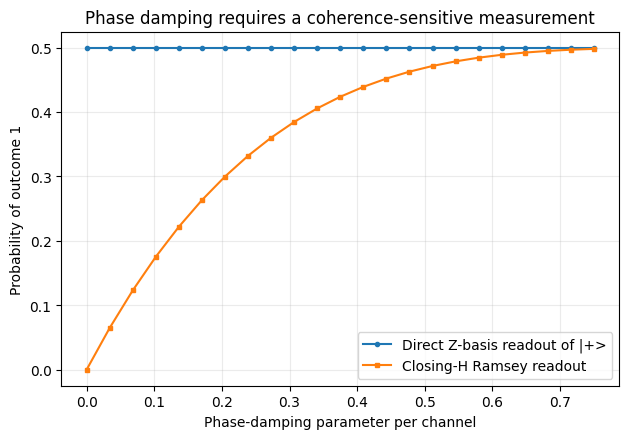

In [3]:
damping_grid = np.linspace(0.0, 0.75, 23)
p_direct, p_ramsey = [], []
for damping in damping_grid:
    rho_direct = density_matrix(phase_damping_basis_circuit(damping, closing_h=False))
    rho_ramsey = density_matrix(phase_damping_basis_circuit(damping, closing_h=True))
    p_direct.append(float(np.real(rho_direct[1, 1])))
    p_ramsey.append(float(np.real(rho_ramsey[1, 1])))

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.plot(damping_grid, p_direct, marker="o", markersize=3, label="Direct Z-basis readout of |+>")
ax.plot(damping_grid, p_ramsey, marker="s", markersize=3, label="Closing-H Ramsey readout")
ax.set_xlabel("Phase-damping parameter per channel")
ax.set_ylabel("Probability of outcome 1")
ax.set_title("Phase damping requires a coherence-sensitive measurement")
ax.grid(alpha=0.25)
ax.legend()
save_figure(fig, "fig01_phase_damping_basis_sensitivity.png")

pd.DataFrame({
    "phase_damping": damping_grid,
    "p1_direct_z": p_direct,
    "p1_closing_h": p_ramsey,
}).to_csv(RESULT_DIR / "phase_damping_basis_sensitivity.csv", index=False)


## 4. Aer calibration of the noisy Ramsey response

The static quantum layer is calibrated before temporal noise is introduced. For each Ramsey phase, Aer returns the pre-readout density matrix. An asymmetric assignment channel with probabilities $p_{01}=P(1\mid0)$ and $p_{10}=P(0\mid1)$ is then applied classically. The reported telegraph mean is fitted to

$$
\mathbb E(X\mid\phi)=\delta+a_c\cos\phi+a_s\sin\phi.
$$

The fitted sine coefficient should be negligible in the absence of coherent phase miscalibration. The effective contrast is $\kappa=(a_c^2+a_s^2)^{1/2}$. The resulting $\delta$ and $\kappa$ are used throughout the ordered statistical experiments.

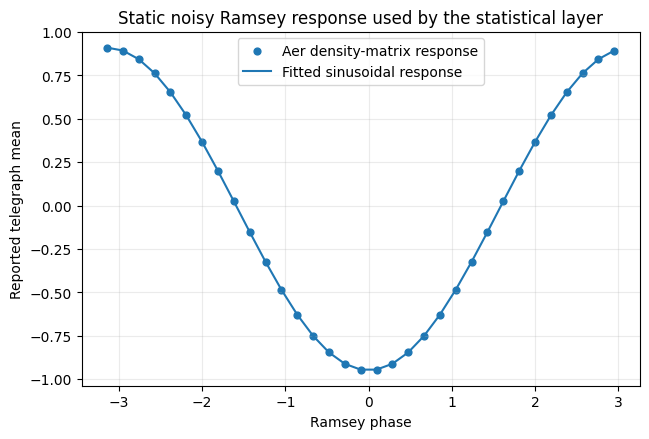

,parameter,estimate
0,delta,-2.000000e-02
1,kappa,9.305604e-01
2,cosine_coefficient,-9.305604e-01
3,sine_coefficient,-1.299567e-16


In [4]:
P01, P10 = 0.015, 0.035
phase_grid = np.linspace(-np.pi, np.pi, 33, endpoint=False)
aer_means = []
for phase in phase_grid:
    rho = density_matrix(ramsey_density_circuit(phase))
    p1_pre = float(np.real(rho[1, 1]))
    p1_reported = apply_readout_one_qubit(p1_pre, P01, P10)
    aer_means.append(2.0 * p1_reported - 1.0)
aer_means = np.asarray(aer_means)

design = np.column_stack([np.ones_like(phase_grid), np.cos(phase_grid), np.sin(phase_grid)])
coef, *_ = np.linalg.lstsq(design, aer_means, rcond=None)
DELTA, A_COS, A_SIN = coef
KAPPA = float(np.hypot(A_COS, A_SIN))
fitted = design @ coef

fig, ax = plt.subplots(figsize=(7.2, 4.6))
ax.scatter(phase_grid, aer_means, s=24, label="Aer density-matrix response")
order = np.argsort(phase_grid)
ax.plot(phase_grid[order], fitted[order], label="Fitted sinusoidal response")
ax.set_xlabel("Ramsey phase")
ax.set_ylabel("Reported telegraph mean")
ax.set_title("Static noisy Ramsey response used by the statistical layer")
ax.grid(alpha=0.25)
ax.legend()
save_figure(fig, "fig00_ramsey_response_calibration.png")

calibration = pd.DataFrame({
    "parameter": ["delta", "kappa", "cosine_coefficient", "sine_coefficient"],
    "estimate": [DELTA, KAPPA, A_COS, A_SIN],
})
calibration.to_csv(RESULT_DIR / "ramsey_response_calibration.csv", index=False)
calibration


## 5. Exact covariance transfer and visible memory

For a stationary Gaussian latent phase with variance $\sigma^2$ and lag covariance $c_h$, the paper proves

$$
\gamma_X(h)=\frac{\kappa^2e^{-\sigma^2}}{2}
\left[e^{c_h}-1+\cos(2\phi_0)\{e^{-c_h}-1\}\right].
$$

At quadrature, the leading term is proportional to $c_h$. At a fringe extremum, the linear term vanishes and the leading term is proportional to $c_h^2$. When $c_h\asymp h^{-\alpha}$, the measured covariance therefore decays as $h^{-\alpha}$ at quadrature and as $h^{-2\alpha}$ at the fringe. A persistent physical phase process can consequently become statistically short-memory after an insensitive measurement.

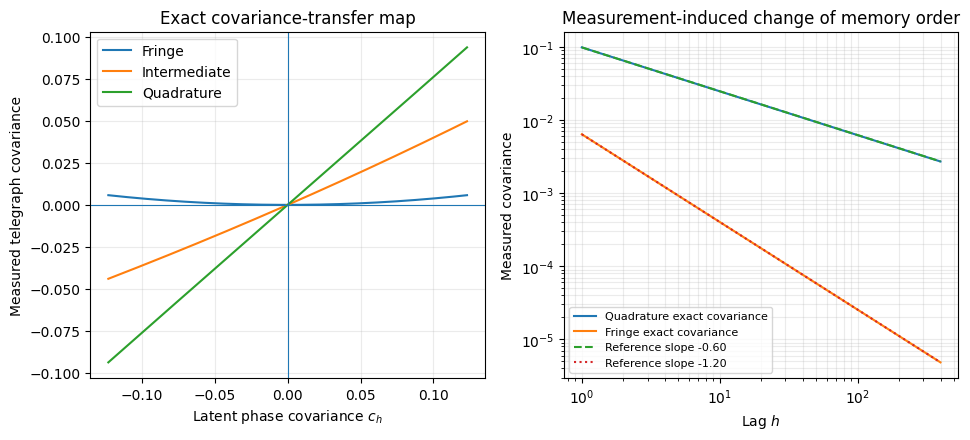

In [5]:
sigma = 0.36
sigma2 = sigma ** 2
c_grid = np.linspace(-0.95 * sigma2, 0.95 * sigma2, 300)
alpha = 0.60
lags = np.arange(1, 400)
latent_cov = sigma2 * lags ** (-alpha)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5))
for phase, label in [(0.0, "Fringe"), (np.pi / 4, "Intermediate"), (np.pi / 2, "Quadrature")]:
    axes[0].plot(c_grid, exact_covariance_transfer(c_grid, sigma2, phase, KAPPA), label=label)
axes[0].axhline(0.0, linewidth=0.8)
axes[0].axvline(0.0, linewidth=0.8)
axes[0].set_xlabel("Latent phase covariance $c_h$")
axes[0].set_ylabel("Measured telegraph covariance")
axes[0].set_title("Exact covariance-transfer map")
axes[0].grid(alpha=0.25)
axes[0].legend()

quad_cov = exact_covariance_transfer(latent_cov, sigma2, np.pi / 2, KAPPA)
fringe_cov = exact_covariance_transfer(latent_cov, sigma2, 0.0, KAPPA)
axes[1].loglog(lags, quad_cov, label="Quadrature exact covariance")
axes[1].loglog(lags, fringe_cov, label="Fringe exact covariance")
axes[1].loglog(lags, quad_cov[0] * lags ** (-alpha), linestyle="--", label=f"Reference slope -{alpha:.2f}")
axes[1].loglog(lags, fringe_cov[0] * lags ** (-2 * alpha), linestyle=":", label=f"Reference slope -{2*alpha:.2f}")
axes[1].set_xlabel("Lag $h$")
axes[1].set_ylabel("Measured covariance")
axes[1].set_title("Measurement-induced change of memory order")
axes[1].grid(alpha=0.25, which="both")
axes[1].legend(fontsize=8)
save_figure(fig, "fig12_covariance_transfer.png")


### Aer-calibrated operating-point experiment

The next simulation uses the same fractional Gaussian phase sequence at two Ramsey operating points. The Bernoulli probability is supplied by the fitted Aer response. The only change is the reference phase. Thus, any difference in the block-level autocorrelation is caused by the measurement map, not by a change in the latent process.

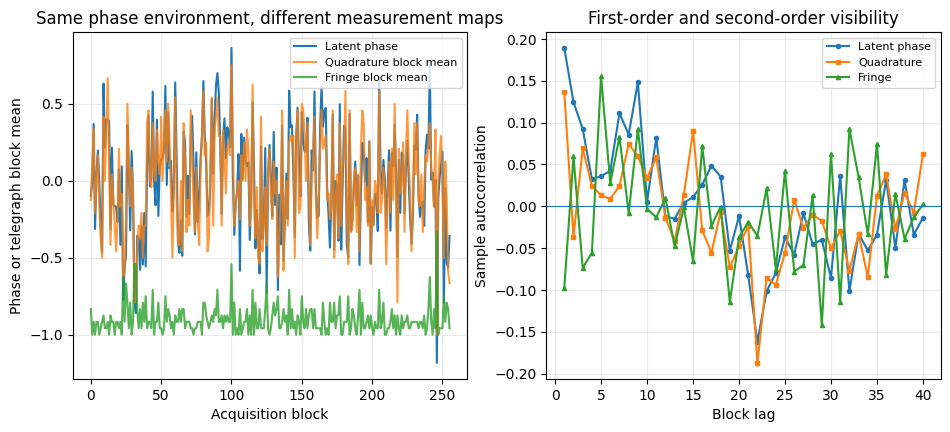

In [6]:
J_transfer, S_transfer = 256, 48
latent_transfer = sample_fgn(J_transfer, 0.70, sigma, np.random.default_rng(SEED + 10))
quad_blocks, _ = simulate_stream(latent_transfer, np.pi / 2, S_transfer, DELTA, KAPPA, np.random.default_rng(SEED + 11))
fringe_blocks, _ = simulate_stream(latent_transfer, 0.0, S_transfer, DELTA, KAPPA, np.random.default_rng(SEED + 12))

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5))
axes[0].plot(latent_transfer, label="Latent phase")
axes[0].plot(quad_blocks, alpha=0.8, label="Quadrature block mean")
axes[0].plot(fringe_blocks, alpha=0.8, label="Fringe block mean")
axes[0].set_xlabel("Acquisition block")
axes[0].set_ylabel("Phase or telegraph block mean")
axes[0].set_title("Same phase environment, different measurement maps")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

lag_axis = np.arange(1, 41)
axes[1].plot(lag_axis, acf(latent_transfer, nlags=40, fft=True)[1:], marker="o", markersize=3, label="Latent phase")
axes[1].plot(lag_axis, acf(quad_blocks, nlags=40, fft=True)[1:], marker="s", markersize=3, label="Quadrature")
axes[1].plot(lag_axis, acf(fringe_blocks, nlags=40, fft=True)[1:], marker="^", markersize=3, label="Fringe")
axes[1].axhline(0.0, linewidth=0.8)
axes[1].set_xlabel("Block lag")
axes[1].set_ylabel("Sample autocorrelation")
axes[1].set_title("First-order and second-order visibility")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
save_figure(fig, "fig12b_aer_operating_point.png")


## 6. Block variance decomposition and acquisition design

For $S$ shots sharing one latent phase, the block mean decomposes as

$$
\overline X_j=m(\epsilon_j)+e_j,
\qquad
\operatorname{Var}(e_j)=\frac{a}{S}.
$$

With $J$ blocks and $N=JS$ total shots, the grand-mean variance is the sum of a conditional shot-noise term and a latent-drift term. At fixed $N$, increasing $S$ does not reduce the first term, but it reduces the number of temporally distinct hardware states. The experiment below evaluates the exact formula for a Gaussian AR(1) phase process and verifies it by Monte Carlo sampling from the Aer-calibrated Bernoulli response.

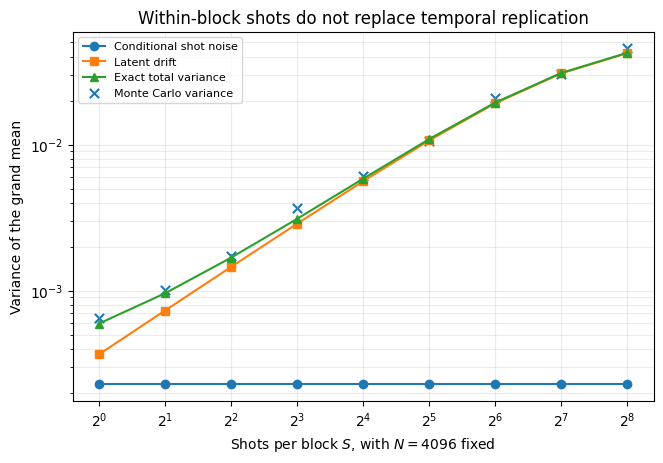

In [7]:
N_total = 4096
S_values = np.array([1, 2, 4, 8, 16, 32, 64, 128, 256])
phi0_block = np.pi / 2
sigma_block = 0.28
sigma2_block = sigma_block ** 2
ar_phi = 0.92

nodes, weights = np.polynomial.hermite.hermgauss(70)
eps_nodes = np.sqrt(2.0) * sigma_block * nodes
m_nodes = ramsey_mean(eps_nodes, phi0_block, DELTA, KAPPA)
a_component = float(np.sum(weights * (1.0 - m_nodes ** 2)) / np.sqrt(np.pi))

exact_components, empirical = [], []
mc_rng = np.random.default_rng(SEED + 20)
for S_block in S_values:
    J_block = N_total // int(S_block)
    h = np.arange(J_block)
    c_h = sigma2_block * ar_phi ** h
    gamma = exact_covariance_transfer(c_h, sigma2_block, phi0_block, KAPPA)
    shot_part = a_component / N_total
    drift_part = (J_block * gamma[0] + 2.0 * np.sum((J_block - h[1:]) * gamma[1:])) / J_block ** 2
    exact_components.append((shot_part, drift_part, shot_part + drift_part))

    means = []
    innovation_sd = sigma_block * np.sqrt(1.0 - ar_phi ** 2)
    for _ in range(220):
        eps = np.empty(J_block)
        eps[0] = mc_rng.normal(scale=sigma_block)
        for j in range(1, J_block):
            eps[j] = ar_phi * eps[j - 1] + mc_rng.normal(scale=innovation_sd)
        _, stream = simulate_stream(eps, phi0_block, int(S_block), DELTA, KAPPA, mc_rng)
        means.append(stream.mean())
    empirical.append(np.var(means, ddof=1))

exact_components = np.asarray(exact_components)
empirical = np.asarray(empirical)
fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(S_values, exact_components[:, 0], marker="o", label="Conditional shot noise")
ax.plot(S_values, exact_components[:, 1], marker="s", label="Latent drift")
ax.plot(S_values, exact_components[:, 2], marker="^", label="Exact total variance")
ax.scatter(S_values, empirical, marker="x", s=45, label="Monte Carlo variance")
ax.set_xscale("log", base=2)
ax.set_yscale("log")
ax.set_xlabel("Shots per block $S$, with $N=4096$ fixed")
ax.set_ylabel("Variance of the grand mean")
ax.set_title("Within-block shots do not replace temporal replication")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=8)
save_figure(fig, "fig13_block_allocation.png")

pd.DataFrame({
    "shots_per_block": S_values,
    "number_of_blocks": N_total // S_values,
    "shot_noise_variance": exact_components[:, 0],
    "latent_drift_variance": exact_components[:, 1],
    "exact_total_variance": exact_components[:, 2],
    "monte_carlo_variance": empirical,
}).to_csv(RESULT_DIR / "block_allocation_variance.csv", index=False)


## 7. Bell and GHZ population and coherence diagnostics

Population support and phase coherence are different inferential targets. For a Bell state, computational-basis outcomes 01 and 10 violate the ideal support, while odd parity after an $X$-basis rotation violates the $X\otimes X$ stabilizer. For an $m$-qubit GHZ state, non-unanimity measures population failure and odd $X$-basis parity measures failure of $X^{\otimes m}$.

Aer evaluates the noisy density matrix after explicit one- and two-qubit depolarizing channels and a phase-damping channel. An independent readout assignment channel is then applied to the full probability vector. The experiment shows why a favorable computational-basis histogram does not establish preserved coherence.

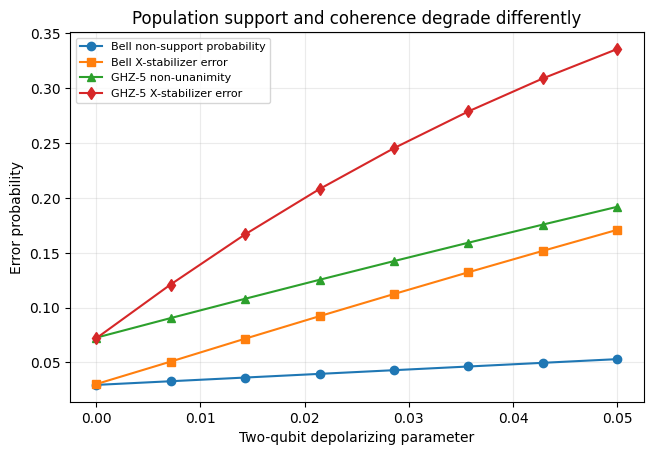

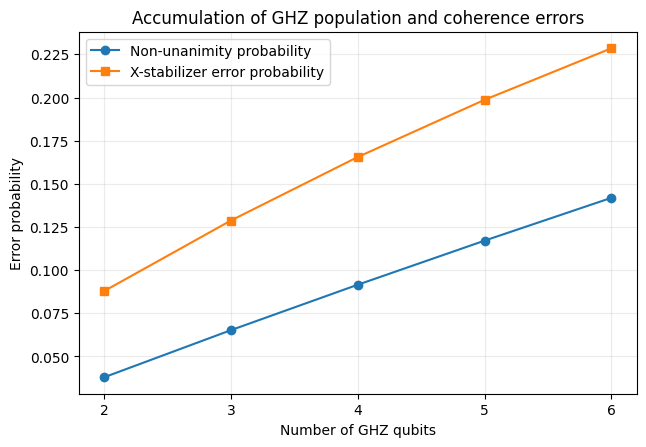

In [8]:
def noisy_probabilities(n, basis, p2, phase_damp, p1=None):
    if p1 is None:
        p1 = max(0.0005, p2 / 8.0)
    rho = density_matrix(ghz_density_circuit(n, basis, p1, p2, phase_damp))
    pre = np.real(np.diag(rho))
    pre = np.maximum(pre, 0.0)
    pre = pre / pre.sum()
    reported = readout_matrix(n, 0.010, 0.020) @ pre
    return reported


def nonunanimity(prob):
    return 1.0 - prob[0] - prob[-1]


def odd_parity(prob):
    return sum(prob[index] for index in range(len(prob)) if int(index).bit_count() % 2 == 1)

p2_grid = np.linspace(0.0, 0.05, 8)
bell_pop, bell_x, ghz5_pop, ghz5_x = [], [], [], []
for p2 in p2_grid:
    phase_damp = min(0.55, 5.0 * p2)
    bell_pop.append(nonunanimity(noisy_probabilities(2, "z", p2, phase_damp)))
    bell_x.append(odd_parity(noisy_probabilities(2, "x", p2, phase_damp)))
    ghz5_pop.append(nonunanimity(noisy_probabilities(5, "z", p2, phase_damp)))
    ghz5_x.append(odd_parity(noisy_probabilities(5, "x", p2, phase_damp)))

fig, ax = plt.subplots(figsize=(7.4, 4.8))
ax.plot(p2_grid, bell_pop, marker="o", label="Bell non-support probability")
ax.plot(p2_grid, bell_x, marker="s", label="Bell X-stabilizer error")
ax.plot(p2_grid, ghz5_pop, marker="^", label="GHZ-5 non-unanimity")
ax.plot(p2_grid, ghz5_x, marker="d", label="GHZ-5 X-stabilizer error")
ax.set_xlabel("Two-qubit depolarizing parameter")
ax.set_ylabel("Error probability")
ax.set_title("Population support and coherence degrade differently")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
save_figure(fig, "fig02_entanglement_degradation.png")

sizes = np.arange(2, 7)
size_pop, size_x = [], []
for n in sizes:
    size_pop.append(nonunanimity(noisy_probabilities(int(n), "z", 0.018, 0.10, p1=0.003)))
    size_x.append(odd_parity(noisy_probabilities(int(n), "x", 0.018, 0.10, p1=0.003)))

fig, ax = plt.subplots(figsize=(7.2, 4.7))
ax.plot(sizes, size_pop, marker="o", label="Non-unanimity probability")
ax.plot(sizes, size_x, marker="s", label="X-stabilizer error probability")
ax.set_xlabel("Number of GHZ qubits")
ax.set_ylabel("Error probability")
ax.set_title("Accumulation of GHZ population and coherence errors")
ax.set_xticks(sizes)
ax.grid(alpha=0.25)
ax.legend()
save_figure(fig, "fig11_ghz_size_scaling.png")

pd.DataFrame({
    "p2": p2_grid,
    "bell_population_error": bell_pop,
    "bell_x_stabilizer_error": bell_x,
    "ghz5_population_error": ghz5_pop,
    "ghz5_x_stabilizer_error": ghz5_x,
}).to_csv(RESULT_DIR / "entanglement_degradation.csv", index=False)


## 8. Ordered Ramsey streams

Each stream contains $J=128$ blocks of $S=32$ shots. The ideal regime uses $\delta=0$ and $\kappa=1$. The static-noisy regime uses the Aer-calibrated $\delta$ and $\kappa$ but no time-varying phase. The colored-drift regime adds fractional Gaussian phase noise with $H=0.70$. The calibration-shift regime adds an abrupt offset halfway through acquisition.

These four regimes separate marginal noise from temporal noise. A static channel may alter the mean and contrast while leaving the order independent. Persistent drift produces positive dependence and low-frequency energy. A change point can resemble persistence in finite data, which is why CUSUM is examined before a global long-memory interpretation.

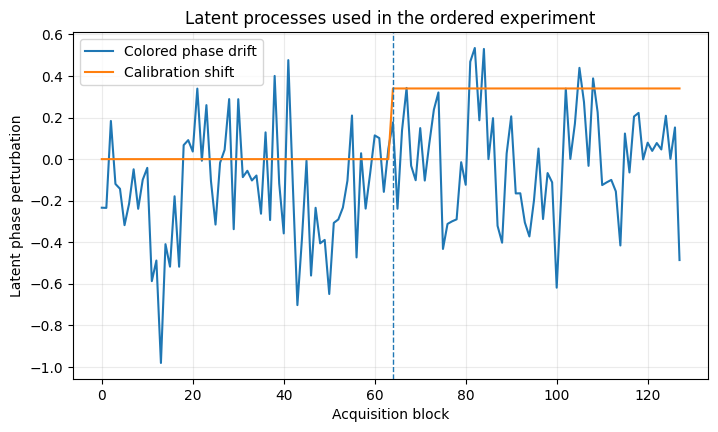

In [9]:
J, S = 128, 32
N = J * S
phi0 = np.pi / 2
stream_rng = np.random.default_rng(SEED + 30)

latent = {
    "Ideal": np.zeros(J),
    "Static noisy": np.zeros(J),
    "Colored phase drift": sample_fgn(J, 0.70, 0.26, stream_rng),
    "Calibration shift": np.r_[np.zeros(J // 2), np.repeat(0.34, J - J // 2)],
}

fig, ax = plt.subplots(figsize=(8.2, 4.5))
ax.plot(latent["Colored phase drift"], label="Colored phase drift")
ax.plot(latent["Calibration shift"], label="Calibration shift")
ax.axvline(J // 2, linestyle="--", linewidth=1.0)
ax.set_xlabel("Acquisition block")
ax.set_ylabel("Latent phase perturbation")
ax.set_title("Latent processes used in the ordered experiment")
ax.grid(alpha=0.25)
ax.legend()
save_figure(fig, "fig03_latent_phase_processes.png")

ordered = {}
for name, eps in latent.items():
    if name == "Ideal":
        ordered[name] = simulate_stream(eps, phi0, S, 0.0, 1.0, stream_rng)
    else:
        ordered[name] = simulate_stream(eps, phi0, S, DELTA, KAPPA, stream_rng)


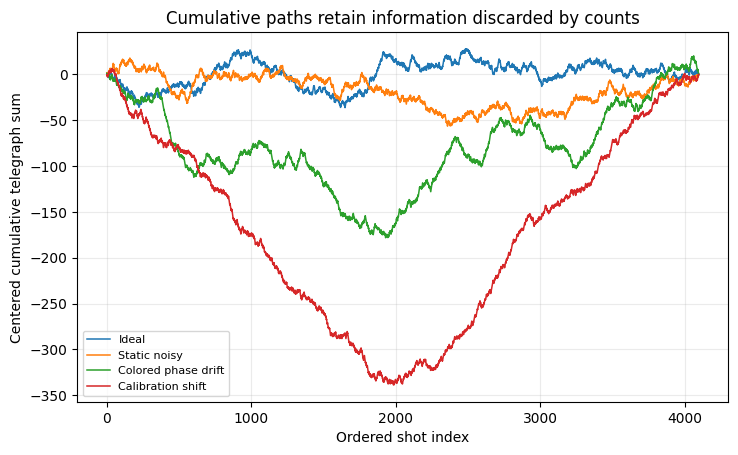

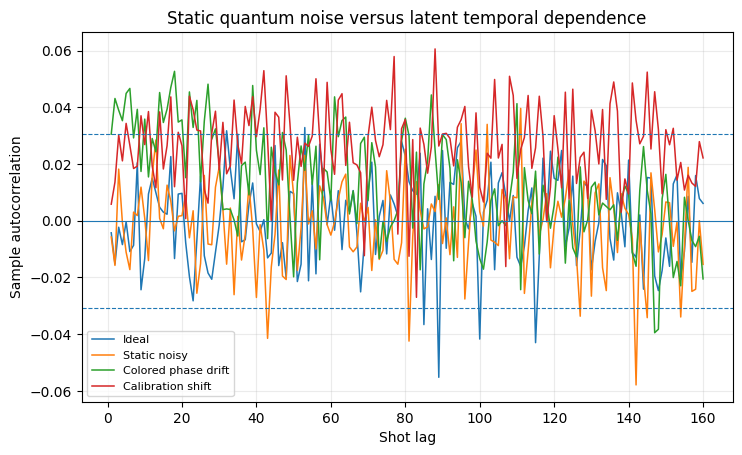

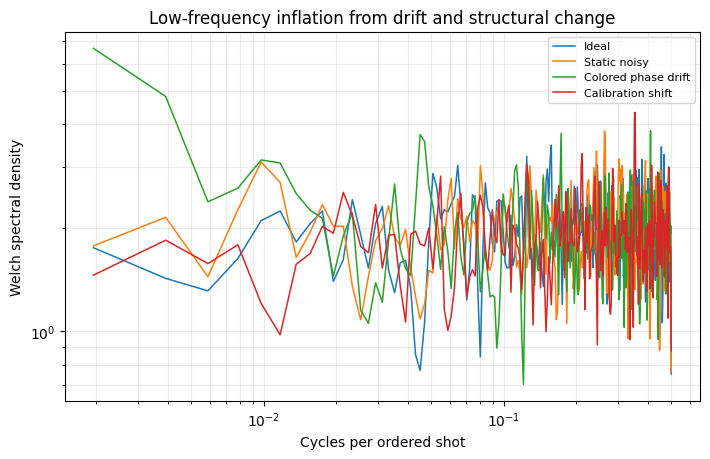

In [10]:
fig, ax = plt.subplots(figsize=(8.4, 4.8))
for name, (_, stream) in ordered.items():
    ax.plot(centered_cusum(stream), linewidth=1.1, label=name)
ax.set_xlabel("Ordered shot index")
ax.set_ylabel("Centered cumulative telegraph sum")
ax.set_title("Cumulative paths retain information discarded by counts")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
save_figure(fig, "fig04_ordered_cumulative_paths.png")

max_lag = 160
fig, ax = plt.subplots(figsize=(8.4, 4.8))
for name, (_, stream) in ordered.items():
    rho = acf(stream, nlags=max_lag, fft=True)
    ax.plot(np.arange(1, max_lag + 1), rho[1:], linewidth=1.1, label=name)
bound = 1.96 / np.sqrt(N)
ax.axhline(bound, linestyle="--", linewidth=0.8)
ax.axhline(-bound, linestyle="--", linewidth=0.8)
ax.axhline(0.0, linewidth=0.8)
ax.set_xlabel("Shot lag")
ax.set_ylabel("Sample autocorrelation")
ax.set_title("Static quantum noise versus latent temporal dependence")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
save_figure(fig, "fig05_autocorrelation_comparison.png")

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for name, (_, stream) in ordered.items():
    frequency, power = welch(stream - stream.mean(), nperseg=512, noverlap=256)
    keep = frequency > 0
    ax.loglog(frequency[keep], power[keep], linewidth=1.1, label=name)
ax.set_xlabel("Cycles per ordered shot")
ax.set_ylabel("Welch spectral density")
ax.set_title("Low-frequency inflation from drift and structural change")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=8)
save_figure(fig, "fig06_power_spectra.png")


<>:19: SyntaxWarning: invalid escape sequence '\l'
<>:19: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_3132/2980485246.py:19: SyntaxWarning: invalid escape sequence '\l'
  ax.set_ylabel("$\log_2$ empirical wavelet energy")


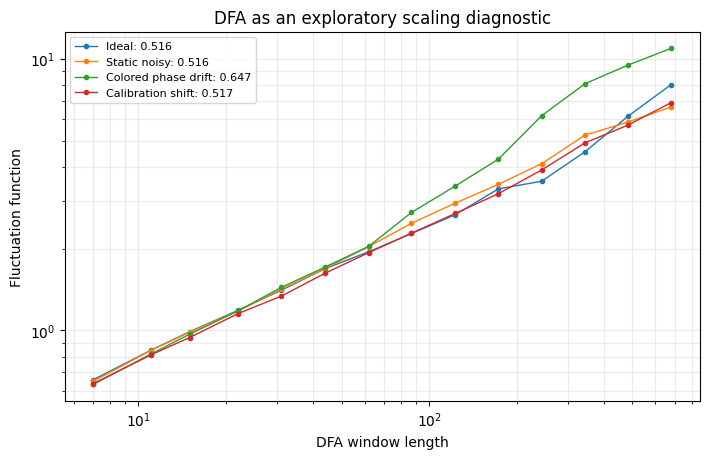

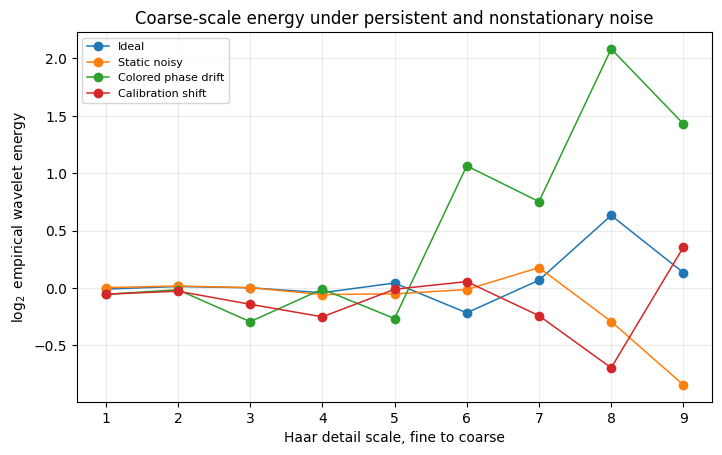

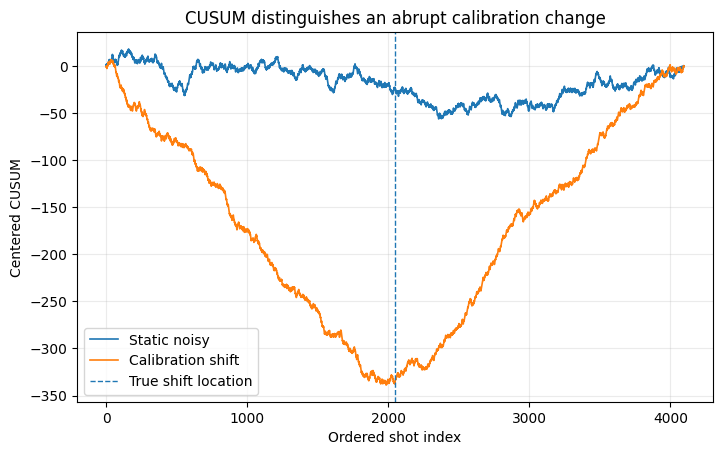

,regime,mean,rho_1,rho_5,ess,tau_int,dfa_exponent,max_abs_cusum
0,Ideal,0.039551,-0.004257,-0.000346,4096.000000,1.000000,0.515526,36.219238
1,Static noisy,-0.024414,-0.005738,-0.011125,4096.000000,1.000000,0.516015,56.431641
2,Colored phase drift,-0.077637,0.030532,0.044887,1127.299117,3.633463,0.647273,178.161133
3,Calibration shift,0.144531,0.005839,0.034316,282.029915,14.523282,0.517118,338.750000


In [11]:
dfa_results = {}
fig, ax = plt.subplots(figsize=(8.2, 4.8))
for name, (_, stream) in ordered.items():
    scales, fluctuation, slope = dfa(stream)
    dfa_results[name] = slope
    ax.loglog(scales, fluctuation, marker="o", markersize=3, linewidth=1.0, label=f"{name}: {slope:.3f}")
ax.set_xlabel("DFA window length")
ax.set_ylabel("Fluctuation function")
ax.set_title("DFA as an exploratory scaling diagnostic")
ax.grid(alpha=0.25, which="both")
ax.legend(fontsize=8)
save_figure(fig, "fig07_dfa_scaling.png")

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for name, (_, stream) in ordered.items():
    scales, energy = haar_logscale(stream)
    ax.plot(scales, energy, marker="o", linewidth=1.1, label=name)
ax.set_xlabel("Haar detail scale, fine to coarse")
ax.set_ylabel("$\log_2$ empirical wavelet energy")
ax.set_title("Coarse-scale energy under persistent and nonstationary noise")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
save_figure(fig, "fig08_haar_logscale.png")

fig, ax = plt.subplots(figsize=(8.2, 4.8))
for name in ["Static noisy", "Calibration shift"]:
    ax.plot(centered_cusum(ordered[name][1]), linewidth=1.2, label=name)
ax.axvline(N // 2, linestyle="--", linewidth=1.0, label="True shift location")
ax.set_xlabel("Ordered shot index")
ax.set_ylabel("Centered CUSUM")
ax.set_title("CUSUM distinguishes an abrupt calibration change")
ax.grid(alpha=0.25)
ax.legend()
save_figure(fig, "fig09_change_point_cusum.png")

summary_rows = []
for name, (_, stream) in ordered.items():
    rho = acf(stream, nlags=5, fft=True)
    ess, tau = ess_initial_positive(stream)
    summary_rows.append({
        "regime": name,
        "mean": stream.mean(),
        "rho_1": rho[1],
        "rho_5": rho[5],
        "ess": ess,
        "tau_int": tau,
        "dfa_exponent": dfa_results[name],
        "max_abs_cusum": np.max(np.abs(centered_cusum(stream))),
    })
ordered_summary = pd.DataFrame(summary_rows)
ordered_summary.to_csv(RESULT_DIR / "ordered_ramsey_summary.csv", index=False)
ordered_summary


## 9. Replication distribution of the scaling estimate

A single DFA slope is variable and method-dependent. The next experiment generates 50 independent streams under the ideal, static-noisy, and colored-drift regimes. The resulting boxplot is a sampling-distribution diagnostic, not a claim that DFA provides a universal estimator of a physical Hurst parameter.

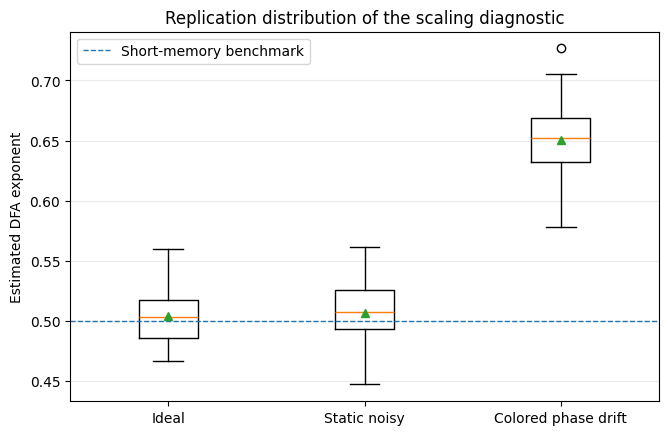

,mean,std
regime,,
Colored phase drift,0.650249,0.028528
Ideal,0.503767,0.021392
Static noisy,0.506183,0.024379


In [12]:
rep_rng = np.random.default_rng(SEED + 40)
records = []
for rep in range(50):
    specifications = {
        "Ideal": (np.zeros(J), 0.0, 1.0),
        "Static noisy": (np.zeros(J), DELTA, KAPPA),
        "Colored phase drift": (sample_fgn(J, 0.70, 0.26, rep_rng), DELTA, KAPPA),
    }
    for name, (eps, delta_use, kappa_use) in specifications.items():
        _, stream = simulate_stream(eps, phi0, S, delta_use, kappa_use, rep_rng)
        records.append({"replication": rep + 1, "regime": name, "dfa_exponent": dfa(stream)[2]})

hurst_df = pd.DataFrame(records)
fig, ax = plt.subplots(figsize=(7.6, 4.8))
regime_order = ["Ideal", "Static noisy", "Colored phase drift"]
values = [hurst_df.loc[hurst_df.regime == name, "dfa_exponent"].to_numpy() for name in regime_order]
ax.boxplot(values, tick_labels=regime_order, showmeans=True)
ax.axhline(0.5, linestyle="--", linewidth=1.0, label="Short-memory benchmark")
ax.set_ylabel("Estimated DFA exponent")
ax.set_title("Replication distribution of the scaling diagnostic")
ax.grid(alpha=0.25, axis="y")
ax.legend()
save_figure(fig, "fig10_hurst_replication_boxplot.png")
hurst_df.to_csv(RESULT_DIR / "dfa_replication_distribution.csv", index=False)
hurst_df.groupby("regime")["dfa_exponent"].agg(["mean", "std"])


## 10. Sentinel-assisted time-local mitigation

The covariance-transfer theorem suggests a concrete design: use a quadrature sentinel to monitor phase drift, even when the target circuit is operated at a different point. The quadrature response has nonzero first derivative and preserves the leading covariance exponent. A near-fringe sentinel has weak local sensitivity and an unstable inverse.

A shared persistent phase sequence drives a quadrature sentinel, a near-fringe sentinel, and a target circuit. The sentinel block mean is converted to a local phase estimate using the Aer-calibrated response. The target is corrected by subtracting the phase-induced shift predicted from that estimate,

$$
\overline X^{\mathrm{corr}}_{t,j}
=\overline X_{t,j}
-\{m_t(\widehat\epsilon_j)-m_t(0)\}.
$$

This simple feed-forward construction is not presented as an optimal mitigation method. It illustrates how the theorem informs circuit construction and why mitigation performance must be evaluated through bias and variance together.

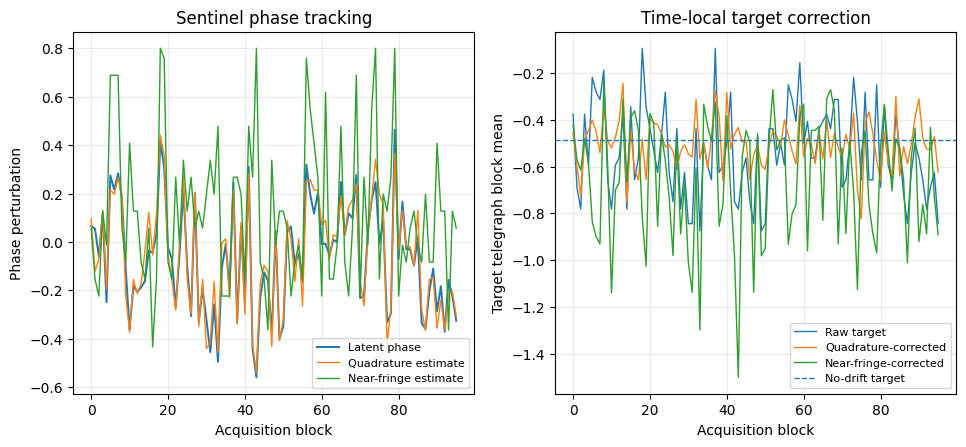

,method,grand_mean,bias_from_no_drift_target,block_rmse,phase_estimation_rmse
0,Raw target,-0.536133,-0.050853,0.197819,NaN
1,Quadrature-sentinel correction,-0.503694,-0.018414,0.106935,0.061065
2,Near-fringe-sentinel correction,-0.657046,-0.171766,0.312409,0.372727


In [13]:
mit_rng = np.random.default_rng(SEED + 50)
J_mit = 96
latent_mit = sample_fgn(J_mit, 0.72, 0.23, mit_rng)
phi_quad, phi_fringe, phi_target = np.pi / 2, 0.12, np.pi / 3

quad_sentinel, _ = simulate_stream(latent_mit, phi_quad, 256, DELTA, KAPPA, mit_rng)
fringe_sentinel, _ = simulate_stream(latent_mit, phi_fringe, 256, DELTA, KAPPA, mit_rng)
target_blocks, _ = simulate_stream(latent_mit, phi_target, 64, DELTA, KAPPA, mit_rng)


def local_linear_phase_estimate(block_mean, phi_reference):
    baseline = ramsey_mean(0.0, phi_reference, DELTA, KAPPA)
    derivative = KAPPA * np.sin(phi_reference)
    return np.clip((block_mean - baseline) / derivative, -0.8, 0.8)

phase_hat_quad = local_linear_phase_estimate(quad_sentinel, phi_quad)
phase_hat_fringe = local_linear_phase_estimate(fringe_sentinel, phi_fringe)

target_no_drift = float(ramsey_mean(0.0, phi_target, DELTA, KAPPA))
corrected_quad = target_blocks - (ramsey_mean(phase_hat_quad, phi_target, DELTA, KAPPA) - target_no_drift)
corrected_fringe = target_blocks - (ramsey_mean(phase_hat_fringe, phi_target, DELTA, KAPPA) - target_no_drift)

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.7))
axes[0].plot(latent_mit, linewidth=1.4, label="Latent phase")
axes[0].plot(phase_hat_quad, linewidth=1.0, label="Quadrature estimate")
axes[0].plot(phase_hat_fringe, linewidth=1.0, label="Near-fringe estimate")
axes[0].set_xlabel("Acquisition block")
axes[0].set_ylabel("Phase perturbation")
axes[0].set_title("Sentinel phase tracking")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(target_blocks, linewidth=1.0, label="Raw target")
axes[1].plot(corrected_quad, linewidth=1.0, label="Quadrature-corrected")
axes[1].plot(corrected_fringe, linewidth=1.0, label="Near-fringe-corrected")
axes[1].axhline(target_no_drift, linestyle="--", linewidth=1.0, label="No-drift target")
axes[1].set_xlabel("Acquisition block")
axes[1].set_ylabel("Target telegraph block mean")
axes[1].set_title("Time-local target correction")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
save_figure(fig, "fig14_sentinel_mitigation.png")

mitigation_summary = pd.DataFrame({
    "method": ["Raw target", "Quadrature-sentinel correction", "Near-fringe-sentinel correction"],
    "grand_mean": [target_blocks.mean(), corrected_quad.mean(), corrected_fringe.mean()],
    "bias_from_no_drift_target": [
        target_blocks.mean() - target_no_drift,
        corrected_quad.mean() - target_no_drift,
        corrected_fringe.mean() - target_no_drift,
    ],
    "block_rmse": [
        np.sqrt(np.mean((target_blocks - target_no_drift) ** 2)),
        np.sqrt(np.mean((corrected_quad - target_no_drift) ** 2)),
        np.sqrt(np.mean((corrected_fringe - target_no_drift) ** 2)),
    ],
    "phase_estimation_rmse": [
        np.nan,
        np.sqrt(np.mean((phase_hat_quad - latent_mit) ** 2)),
        np.sqrt(np.mean((phase_hat_fringe - latent_mit) ** 2)),
    ],
})
mitigation_summary.to_csv(RESULT_DIR / "sentinel_mitigation_summary.csv", index=False)
mitigation_summary


## 11. Interpretation and hardware transition

The notebook illustrates four points. The measurement basis determines which channel components become visible. The Ramsey operating phase determines the order through which latent covariance enters the measured record. Static quantum noise changes marginal behavior but does not itself create serial dependence. Finally, shots within one quasi-static hardware state and replication across hardware states reduce different uncertainty components.

The fractional Gaussian model is a controlled persistent alternative, not a unique microscopic claim. Hardware data should compare fractional, state-space, hidden-state, telegraph, and change-point explanations. A useful hardware implementation would interleave quadrature sentinels with target circuits, preserve block timestamps and job boundaries, and report the full bias-variance effect of time-local correction. The hardware analogue of `fig14_sentinel_mitigation.png` would be a strong empirical figure for the paper.

In [14]:
manifest = {
    "title": "Qiskit 2.x and Aer companion for measurement-aware quantum noise inference",
    "seed": SEED,
    "versions": VERSIONS,
    "ramsey_calibration": {
        "delta": float(DELTA),
        "kappa": float(KAPPA),
        "cosine_coefficient": float(A_COS),
        "sine_coefficient": float(A_SIN),
        "readout_p01": P01,
        "readout_p10": P10,
    },
    "figures": sorted(path.name for path in FIG_DIR.glob("*.png")),
    "results": sorted(path.name for path in RESULT_DIR.glob("*.csv")),
    "intended_repository": "https://github.com/BraniV/QNoise",
}
with open(RESULT_DIR / "run_manifest.json", "w", encoding="utf-8") as handle:
    json.dump(manifest, handle, indent=2)
print(json.dumps(manifest, indent=2))


{
  "title": "Qiskit 2.x and Aer companion for measurement-aware quantum noise inference",
  "seed": 20260719,
  "versions": {
    "python": "3.13.5",
    "platform": "Linux-4.4.0-x86_64-with-glibc2.41",
    "qiskit": "2.4.2",
    "qiskit_aer": "0.17.2",
    "numpy": "2.3.5",
    "pandas": "2.2.3",
    "pywavelets": "1.8.0"
  },
  "ramsey_calibration": {
    "delta": -0.019999999999999237,
    "kappa": 0.9305604488485779,
    "cosine_coefficient": -0.9305604488485779,
    "sine_coefficient": -1.2995668662607785e-16,
    "readout_p01": 0.015,
    "readout_p10": 0.035
  },
  "figures": [
    "fig00_ramsey_response_calibration.png",
    "fig01_phase_damping_basis_sensitivity.png",
    "fig02_entanglement_degradation.png",
    "fig03_latent_phase_processes.png",
    "fig04_ordered_cumulative_paths.png",
    "fig05_autocorrelation_comparison.png",
    "fig06_power_spectra.png",
    "fig07_dfa_scaling.png",
    "fig08_haar_logscale.png",
    "fig09_change_point_cusum.png",
    "fig10_hurst_r

## 12. Paragraph for the manuscript

> **Computational companion.** The theoretical results are accompanied by a reproducible Qiskit 2.x and Qiskit Aer notebook available at `https://github.com/BraniV/QNoise`. The notebook uses Aer to evaluate the conditional quantum experiment and represents temporal hardware variation through explicitly ordered acquisition blocks driven by a specified latent phase process. This separation mirrors the statistical model: static channel and readout errors alter the marginal Ramsey response, while dependence is induced by persistence of the latent environment across blocks. The notebook regenerates the principal figures, validates the exact covariance-transfer and block-variance formulas, implements Bell and GHZ population and stabilizer diagnostics, and illustrates sentinel-assisted time-local mitigation. Fixed seeds, software versions, circuit definitions, fitted scale ranges, and machine-readable numerical summaries are recorded with every run.

The repository should contain this notebook, the paper source, the `Figs` and `Results` directories, `requirements.txt`, and a concise README explaining the distinction between static Aer noise and temporally evolving latent noise.